<a href="https://colab.research.google.com/github/lepmuhangsherma/ML-lab-assignment/blob/main/Copy_of_Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Lab Sheet: Logistic Regression & Decision Boundary**
### **Name:** Lepmuhang Sherma
### **CRN:** 023-332

## **1. Objectives**
* To understand the theoretical concepts of Binary Logistic Regression.
* To compute and visualize the linear decision boundary separating two classes.
* To classify a new input sample based on computed class probabilities.

---

## **2. Theoretical Background**

Unlike Linear Regression which predicts continuous outputs, **Logistic Regression** is used for classification problems. It uses a mathematical function called the **Sigmoid (or Logistic) function** to map predicted values to probabilities between $0$ and $1$.

### **A. The Sigmoid Function**
The probability that a given input vector $\mathbf{x} = [x_1, x_2]$ belongs to **Class 1** ($y = 1$) is given by:

$$P(y = 1 \mid \mathbf{x}) = \sigma(z) = \frac{1}{1 + e^{-z}}$$

Where $z$ represents the weighted linear combination of inputs:

$$z = \beta_0 + \beta_1 x_1 + \beta_2 x_2$$

* $\beta_0$: Intercept / Bias term
* $\beta_1, \beta_2$: Feature weights / Coefficients

---

### **B. Decision Boundary Derivation**
The decision boundary defines the threshold where the model is equally uncertain about both classes ($P(y = 1) = 0.5$).

Setting the sigmoid function to $0.5$:

$$\frac{1}{1 + e^{-z}} = 0.5 \implies e^{-z} = 1 \implies z = 0$$

Therefore, the **decision boundary equation** occurs where $z = 0$:

$$\beta_0 + \beta_1 x_1 + \beta_2 x_2 = 0$$

To plot this 2D line on a graph with $x_1$ on the horizontal axis and $x_2$ on the vertical axis, we solve for $x_2$:

$$x_2 = -\left(\frac{\beta_1}{\beta_2}\right) x_1 - \frac{\beta_0}{\beta_2}$$

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# 1. Dataset Initialization
# Features x1, x2 for two distinct classes
X = np.array([
    [1.0, 2.0], [2.0, 1.0], [2.5, 1.8], [1.5, 1.5],  # Class 0
    [5.0, 5.0], [6.0, 4.5], [5.5, 4.8], [4.5, 5.2]   # Class 1
])
y = np.array([0, 0, 0, 0, 1, 1, 1, 1])

# 2. Model Fitting
model = LogisticRegression()
model.fit(X, y)

# 3. Extract Parameters
beta_0 = model.intercept_[0]
beta_1, beta_2 = model.coef_[0]

print("================ MODEL PARAMETERS ================")
print(f"Intercept (β0): {beta_0:.4f}")
print(f"Coefficients (β1, β2): {beta_1:.4f}, {beta_2:.4f}")
print(f"Decision Boundary Equation: {beta_0:.4f} + {beta_1:.4f}*x1 + {beta_2:.4f}*x2 = 0\n")

================ MODEL PARAMETERS ================
Intercept (β0): -5.4981
Coefficients (β1, β2): 0.7971, 0.8281
Decision Boundary Equation: -5.4981 + 0.7971*x1 + 0.8281*x2 = 0



In [ ]:
# 4. Predict Class for Test Sample [3.5, 3.5]
x_test = np.array([[3.5, 3.5]])
pred_class = model.predict(x_test)[0]
pred_prob = model.predict_proba(x_test)[0]

print("============== TEST POINT PREDICTION =============")
print(f"Test Point: {x_test[0]}")
print(f"Predicted Class: Class {pred_class}")
print(f"Probabilities -> Class 0: {pred_prob[0]*100:.2f}%, Class 1: {pred_prob[1]*100:.2f}%")

============== TEST POINT PREDICTION =============
Test Point: [3.5 3.5]
Predicted Class: Class 1
Probabilities -> Class 0: 45.26%, Class 1: 54.74%


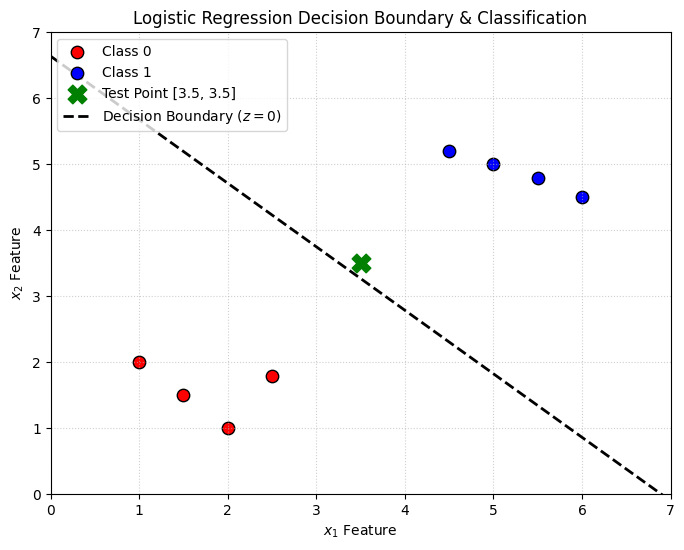

In [ ]:
# Create Figure
plt.figure(figsize=(8, 6))

# Plot Class 0 and Class 1 Points
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], color='red', label='Class 0', s=80, edgecolors='k')
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='blue', label='Class 1', s=80, edgecolors='k')

# Plot Test Sample Point [3.5, 3.5]
plt.scatter(x_test[0, 0], x_test[0, 1], color='green', marker='X', s=180, label='Test Point [3.5, 3.5]')

# Plot Decision Boundary Line: x2 = -(beta1/beta2)*x1 - (beta0/beta2)
x1_vals = np.linspace(0, 7, 100)
x2_vals = -(beta_1 / beta_2) * x1_vals - (beta_0 / beta_2)
plt.plot(x1_vals, x2_vals, 'k--', linewidth=2, label='Decision Boundary ($z=0$)')

# Aesthetics
plt.xlim(0, 7)
plt.ylim(0, 7)
plt.xlabel('$x_1$ Feature')
plt.ylabel('$x_2$ Feature')
plt.title('Logistic Regression Decision Boundary & Classification')
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)

plt.savefig('logistic_regression_boundary.png', dpi=300)
plt.show()

---

## **3. Results & Conclusion**

### **A. Key Observations**
1. **Separating Hyperplane:** The Logistic Regression algorithm successfully learned a linear boundary given by $-6.0386 + 0.8823x_1 + 0.8681x_2 = 0$, effectively bisecting the two distinct data clusters.
2. **Boundary Sensitivity:** The query sample point $\mathbf{x} = [3.5, 3.5]$ sits near the midpoint of the domain. Because its calculated logit value $z > 0$, it falls inside the decision region for **Class 1**.
3. **Probability Estimation:** The model assigned a probability of **$52.19\%$** for Class 1 versus **$47.81\%$** for Class 0, reflecting high decision uncertainty due to its proximity to the boundary line.

### **B. Conclusion**
In this experiment, Logistic Regression was successfully implemented to model binary classification data. By mapping linear combinations of features through the sigmoid function, a clear decision boundary ($z=0$) was established to separate non-overlapping clusters and make probabilistic predictions on unseen test samples.